In [1]:
import pandas as pd
import ast
import re
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import KeyedVectors
from gensim.utils import simple_preprocess
from gensim.models import Word2Vec
from pathlib import Path
from sentence_transformers import SentenceTransformer

In [2]:

#cambiar como sea relevante la direccion. esto asume esta en el mismo directorio
df = pd.read_csv("../data/libros.csv")

print(f"Cantidad de libros: {len(df)}")
df.head()

Cantidad de libros: 120


,id,titulo,autores,generos,serie,sinopsis,url_libro,categoria_origen,fecha_extraccion
0,1,El papá de las bellezas,"[""Felipe Trigo""]","[""Realista"", ""Relato""]",NaN,"El papá de las bellezas , una obra maestra de ...",https://ww3.lectulandia.com/book/el-papa-de-la...,Realismo,2026-09-11
1,2,La última cerilla,"[""Marie Vareille""]","[""Novela"", ""Psicológico"", ""Realista""]",NaN,Las cifras no mienten: tres de cada cuatro niñ...,https://ww3.lectulandia.com/book/la-ultima-cer...,Realismo,2026-09-11
2,3,La enjuta,"[""Víctor Català""]","[""Realista"", ""Relato""]",NaN,En estos relatos la autora presenta una radiog...,https://ww3.lectulandia.com/book/la-enjuta/,Realismo,2026-09-11
3,4,En el camping,"[""Soledad Puértolas""]","[""Realista"", ""Relato""]",NaN,El esplendor de Soledad Puértolas en su madure...,https://ww3.lectulandia.com/book/en-el-camping/,Realismo,2026-09-11
4,5,Koljós,"[""Emmanuel Carrère""]","[""Ensayo"", ""Memorias"", ""Novela"", ""Realista""]",NaN,"Un libro total, una construcción narrativa des...",https://ww3.lectulandia.com/book/koljos/,Realismo,2026-09-11


In [3]:
def convertir_a_string(valor):
    if pd.isna(valor):
        return ""
    
    if isinstance(valor, str):
        try:
            valor_parseado = ast.literal_eval(valor)
            
            if isinstance(valor_parseado, list):
                return " ".join(str(x) for x in valor_parseado)
            
            return str(valor_parseado)
        
        except (ValueError, SyntaxError):
            return valor
    
    if isinstance(valor, list):
        return " ".join(str(x) for x in valor)
    
    return str(valor)


In [4]:
columnas = [
    "titulo",
    "autores",
    "generos",
    "serie",
    "sinopsis"
]

for columna in columnas:
    df[columna] = df[columna].apply(convertir_a_string)


CAMBIAR LA VARIABLE DE PURO!!


In [5]:
df["puro"] = df[columnas].agg(" ".join, axis=1)

df["puro"] = (
    df["puro"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)


In [6]:
df[["titulo", "autores", "generos", "serie", "sinopsis", "puro"]].head()


,titulo,autores,generos,serie,sinopsis,puro
0,El papá de las bellezas,Felipe Trigo,Realista Relato,,"El papá de las bellezas , una obra maestra de ...",El papá de las bellezas Felipe Trigo Realista ...
1,La última cerilla,Marie Vareille,Novela Psicológico Realista,,Las cifras no mienten: tres de cada cuatro niñ...,La última cerilla Marie Vareille Novela Psicol...
2,La enjuta,Víctor Català,Realista Relato,,En estos relatos la autora presenta una radiog...,La enjuta Víctor Català Realista Relato En est...
3,En el camping,Soledad Puértolas,Realista Relato,,El esplendor de Soledad Puértolas en su madure...,En el camping Soledad Puértolas Realista Relat...
4,Koljós,Emmanuel Carrère,Ensayo Memorias Novela Realista,,"Un libro total, una construcción narrativa des...",Koljós Emmanuel Carrère Ensayo Memorias Novela...


COPIAMOS LOS DF PARA HACER TF - IDF Y WORD2VEC

In [7]:
#copiamos el df base para usarlo en todos los items
df_tfidf = df.copy()
df_word2vec = df.copy()

limpieza!!

In [8]:
STOPWORDS_ES = {
    "a", "al", "algo", "algunas", "algunos", "ante", "antes", "como",
    "con", "contra", "cual", "cuando", "de", "del", "desde", "donde",
    "dos", "el", "ella", "ellas", "ellos", "en", "entre", "era", "es",
    "esa", "esas", "ese", "eso", "esos", "esta", "estas", "este", "esto",
    "estos", "fue", "ha", "han", "hasta", "hay", "la", "las", "le", "les",
    "lo", "los", "más", "me", "mi", "mis", "muy", "no", "nos", "o", "para",
    "pero", "por", "que", "qué", "se", "sea", "ser", "si", "sí", "sin",
    "sobre", "son", "su", "sus", "también", "te", "tiene", "tienen", "todo",
    "todos", "tu", "tus", "un", "una", "uno", "unos", "y", "ya"
}

In [9]:
def remover_acentos(texto):
    texto = re.sub(r"[áàäâãå]", "a", texto)
    texto = re.sub(r"[éèëê]", "e", texto)
    texto = re.sub(r"[íìïî]", "i", texto)
    texto = re.sub(r"[óòöôõ]", "o", texto)
    texto = re.sub(r"[úùüû]", "u", texto)
    texto = texto.replace("ñ", "n")
    
    return texto

In [10]:


def limpiar_texto(texto):
    # 1. Lowercase
    texto = texto.lower()

    # 2. Remover acentos
    texto = remover_acentos(texto)

    # 3. Remover stopwords
    palabras = texto.split()
    palabras = [
        palabra for palabra in palabras
        if palabra not in STOPWORDS_ES
    ]

    return " ".join(palabras)


# Modificamos directamente la columna "puro"
df_tfidf["puro"] = df_tfidf["puro"].apply(limpiar_texto)



In [11]:
df_tfidf["puro"].head()

0    papa bellezas felipe trigo realista relato pap...
1    ultima cerilla marie vareille novela psicologi...
2    enjuta victor catala realista relato relatos a...
3    camping soledad puertolas realista relato espl...
4    koljos emmanuel carrere ensayo memorias novela...
Name: puro, dtype: str

In [12]:

# Crear el vectorizador
vectorizador = TfidfVectorizer()

# Calcular TF-IDF
matriz_tfidf = vectorizador.fit_transform(df_tfidf["puro"])

# Guardar el vector de cada libro en df["vec"]
df_tfidf["vec"] = list(matriz_tfidf.toarray())

In [13]:
vector = df_tfidf["vec"].iloc[0]
terminos = vectorizador.get_feature_names_out()

for termino, valor in zip(terminos, vector):
    if valor > 0:
        print(f"{termino}: {valor:.4f}")

ambiente: 0.1235
audaz: 0.1342
belleza: 0.1101
bellezas: 0.2684
bello: 0.1342
cambio: 0.1012
complejidad: 0.1235
contexto: 0.1160
cotidiana: 0.1160
crea: 0.1342
critica: 0.0830
cuidadoso: 0.1342
deseos: 0.1101
despliega: 0.1160
enfoque: 0.1342
entrelaza: 0.1342
entrelazado: 0.1342
espana: 0.0977
estetica: 0.1342
estilo: 0.0946
evocador: 0.1235
evolucion: 0.1235
examinan: 0.1342
felipe: 0.2025
femenina: 0.1053
grotesco: 0.1342
hacia: 0.0894
humanas: 0.0946
humanos: 0.1101
inicios: 0.1342
invita: 0.1053
lector: 0.0764
libro: 0.0657
maestra: 0.1012
motivaciones: 0.1342
narrativo: 0.1053
obra: 0.0678
papa: 0.2684
papel: 0.1101
personajes: 0.0736
presentando: 0.1342
profundamente: 0.1012
propias: 0.1160
publicado: 0.1101
realidad: 0.0795
realista: 0.0263
refleja: 0.1101
reflexion: 0.1160
relaciones: 0.0946
relato: 0.0597
sensualidad: 0.1160
siglo: 0.0919
social: 0.1837
sociedad: 0.0830
sumerge: 0.1160
tensiones: 0.1160
transformaciones: 0.1342
trigo: 0.3159
vibrante: 0.1235
vida: 0.0430
xx:

In [14]:
vector = df_tfidf["vec"].iloc[0]
terminos = vectorizador.get_feature_names_out()

top_10 = sorted(
    zip(terminos, vector),
    key=lambda x: x[1],
    reverse=True
)[:10]

for termino, valor in top_10:
    print(f"{termino}: {valor:.4f}")

trigo: 0.3159
bellezas: 0.2684
papa: 0.2684
felipe: 0.2025
social: 0.1837
audaz: 0.1342
bello: 0.1342
crea: 0.1342
cuidadoso: 0.1342
enfoque: 0.1342


GUARDAR EL VECTORIZADO


In [15]:
# Guardar los vectores en un archivo físico
np.savez_compressed(
    "vectores_libros.npz",
    ids=df_tfidf["id"].to_numpy(),
    vectores=np.stack(df_tfidf["vec"].to_numpy())
)



In [16]:
datos = np.load("vectores_libros.npz")

ids = datos["ids"]
vectores = datos["vectores"]

vector = vectores[0]
terminos = vectorizador.get_feature_names_out()

top_10 = sorted(
    zip(terminos, vector),
    key=lambda x: x[1],
    reverse=True
)[:10]

for termino, valor in top_10:
    print(f"{termino}: {valor:.4f}")

trigo: 0.3159
bellezas: 0.2684
papa: 0.2684
felipe: 0.2025
social: 0.1837
audaz: 0.1342
bello: 0.1342
crea: 0.1342
cuidadoso: 0.1342
enfoque: 0.1342


PARTE B:  Word2Vec

In [17]:
df_word2vec["puro"].head()[0]

'El papá de las bellezas Felipe Trigo Realista Relato El papá de las bellezas , una obra maestra de Felipe Trigo, despliega un enfoque audaz hacia las relaciones humanas y la complejidad de la belleza femenina. El libro, publicado en el contexto de un cambio social a inicios del siglo XX en España, refleja las tensiones y transformaciones de una sociedad en evolución. Con un estilo narrativo cuidadoso y evocador, Trigo sumerge al lector en una realidad donde la sensualidad se entrelaza con la crítica social, presentando personajes profundamente humanos que examinan sus propias motivaciones y deseos. Este entrelazado de lo bello y lo grotesco crea un ambiente vibrante que invita a la reflexión sobre el papel de la estética en la vida cotidiana.'

In [18]:

# 1. Cargar el modelo preentrenado
modelo = KeyedVectors.load_word2vec_format(
    "../data/SBW-vectors-300-min5.bin.gz",
    binary=True
)

In [19]:

# 2. Función para vectorizar cada libro
def vectorizar_texto(texto):
    if not isinstance(texto, str) or not texto.strip():
        return np.zeros(300, dtype=np.float32)

    palabras = texto.split()

    # Conservar únicamente las palabras conocidas por el modelo
    vectores = [
        modelo[palabra]
        for palabra in palabras
        if palabra in modelo
    ]

    # Si ninguna palabra existe en el vocabulario
    if not vectores:
        return np.zeros(300, dtype=np.float32)

    # Promediar los vectores de las palabras
    return np.mean(vectores, axis=0)

In [20]:
# Crear un DataFrame nuevo con las columnas id y vec_sbw
df_sbw = df_word2vec[["id", "puro"]].copy()

df_sbw["vec_sbw"] = df_sbw["puro"].apply(vectorizar_texto)

# Conservar únicamente las columnas necesarias
df_sbw = df_sbw[["id", "vec_sbw"]]

# Verificar dimensiones del vector
print(df_sbw["vec_sbw"].iloc[0].shape)  # (300,)

# Mostrar las primeras filas
df_sbw.head()

(300,)


,id,vec_sbw
0,1,"[-0.015811114, -0.083094604, 0.067930214, -0.1..."
1,2,"[-0.04534435, -0.059153963, 0.07750422, -0.090..."
2,3,"[-0.013389647, -0.08637572, 0.091473505, -0.09..."
3,4,"[0.00068464753, -0.03950356, 0.0801799, -0.081..."
4,5,"[-0.035262242, -0.044648714, 0.041821692, -0.1..."


la idea es usar el vector para las busquedas y luego usar el id en el df de los libros

In [21]:
columnas_jugo = [
    "generos",
    "sinopsis"
]

df_word2vec["jugo"] = df_word2vec[columnas_jugo].agg(" ".join, axis=1)

df_word2vec["jugo"] = (
    df_word2vec["jugo"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [22]:
textos = df_word2vec["jugo"].astype(str)


# Separar en oraciones y tokenizar
oraciones = []

for texto in textos:
    frases = re.split(r'[.!?¿¡\n]+', texto)

    for frase in frases:
        palabras = simple_preprocess(
            frase,
            deacc=True,  # Quita acentos
            min_len=2
        )

        if palabras:
            oraciones.append(palabras)

In [23]:

# Entrenar el modelo propio
modelo_propio = Word2Vec(
    sentences=oraciones,
    vector_size=100,
    window=5,
    min_count=2,
    sg=1,
    workers=4,
    seed=42,
    epochs=10
)

print("Cantidad de oraciones:", len(oraciones))
print("Tamaño del vocabulario:", len(modelo_propio.wv))

Cantidad de oraciones:

 732
Tamaño del vocabulario: 1679


ITEM C: Modelo de oración: SBERT

In [24]:
# 1. Cargar el corpus
# Si estás en un .py mantené __file__. Si estás en un .ipynb usá Path.cwd() o la ruta al CSV:
df_sbert = pd.read_csv("../data/libros.csv")
sinopsis_crudas = df_sbert['sinopsis'].tolist()

# 2. Cargar el modelo pre-entrenado
model_name = 'distiluse-base-multilingual-cased-v1'
model = SentenceTransformer(model_name)

# 3. Reporte de propiedades del modelo
dim = model.get_embedding_dimension()
max_seq_len = model.max_seq_length

print(f"Dimensión del embedding: {dim}")
print(f"Límite de tokens del modelo (max_seq_length): {max_seq_len}")

# 4. Cálculo de documentos truncados
tokenizer = model.tokenizer
token_counts = [len(tokenizer.encode(texto, truncation=False)) for texto in sinopsis_crudas]

truncados = sum(1 for c in token_counts if c > max_seq_len)
pct_truncados = (truncados / len(sinopsis_crudas)) * 100

print(f"Documentos que superan el límite y se truncan: {truncados} de {len(sinopsis_crudas)} ({pct_truncados:.1f}%)")

# 5. Generar embeddings y mantenerlos en memoria
embeddings_sbert = model.encode(sinopsis_crudas, show_progress_bar=True, normalize_embeddings=True)

# Guardado en memoria: disponible como array NumPy y como columna del DataFrame
df_sbert['embedding_sbert'] = list(embeddings_sbert)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (166 > 128). Running this sequence through the model will result in indexing errors


Dimensión del embedding: 512
Límite de tokens del modelo (max_seq_length): 128
Documentos que superan el límite y se truncan: 101 de 120 (84.2%)


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

## Parte D — Comparación y visualización de los espacios

Comparamos los tres espacios construidos en las partes A–C sobre el mismo corpus de 120 libros y las mismas consultas:

| Espacio | Variable | Dimensión |
| --- | --- | --- |
| TF-IDF | `df_tfidf["vec"]` | tamaño del vocabulario |
| Word2Vec promedio (SBW) | `df_sbw["vec_sbw"]` | 300 |
| SBERT (distiluse) | `embeddings_sbert` | 512 |

Las tres representaciones están alineadas fila a fila (todas derivan del mismo `data/libros.csv` leído en el mismo orden), así que la fila `i` es el mismo libro en los tres espacios.

In [25]:
# --- D.0  Infraestructura común: matrices alineadas y consulta por espacio ---
import json
import ast
from collections import Counter

import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from IPython.display import display

# Identificadores y títulos en el orden de las filas (común a los tres espacios)
doc_ids = df["id"].to_numpy()
titulos = df["titulo"].to_numpy()

# Matriz densa (120 x d) por espacio
X_tfidf = np.vstack(df_tfidf["vec"].to_numpy())          # (120, |vocab|)
X_sbw   = np.vstack(df_sbw["vec_sbw"].to_numpy())        # (120, 300)
X_sbert = np.vstack(df_sbert["embedding_sbert"].to_numpy())  # (120, 512)

print("TF-IDF :", X_tfidf.shape)
print("SBW    :", X_sbw.shape)
print("SBERT  :", X_sbert.shape)

# Embebido de la CONSULTA en cada espacio, replicando el mismo preproceso que
# se usó para los documentos, para que la comparación sea justa.
def q_tfidf(texto):
    # mismos pasos de limpieza que df_tfidf["puro"]
    return vectorizador.transform([limpiar_texto(texto)]).toarray()

def q_sbw(texto):
    # mismo promedio de vectores de palabra que vectorizar_texto() aplicó a "puro"
    return vectorizar_texto(texto).reshape(1, -1)

def q_sbert(texto):
    return model.encode([texto], normalize_embeddings=True)

# nombre -> (matriz de documentos, función que embebe la consulta)
espacios = {
    "TF-IDF":          (X_tfidf, q_tfidf),
    "Word2Vec (SBW)":  (X_sbw,   q_sbw),
    "SBERT":           (X_sbert, q_sbert),
}

TF-IDF : (120, 5197)
SBW    : (120, 300)
SBERT  : (120, 512)


### D.1 — Ranking lado a lado

Para cada consulta embebemos el texto en cada espacio y ordenamos los 120 libros por similitud coseno. Mostramos el top-5 de los tres modelos en paralelo; `✓` marca los documentos que el *gold standard* de `queries.json` considera relevantes y `·` los que no.

In [26]:
# Cargar el conjunto de evaluación (juicios de relevancia hechos a mano)
with open("../queries.json", encoding="utf-8") as f:
    QUERIES = {c["id"]: c for c in json.load(f)["consultas"]}

def gold_ids(qid):
    return {r["id"] for r in QUERIES[qid]["relevantes"]}

def rankear(texto, X, qfn, k=5):
    q = qfn(texto)
    sims = cosine_similarity(q, X)[0]
    idx = np.argsort(sims)[::-1][:k]
    return idx, sims[idx]

def tabla_ranking(qid, k=5):
    c = QUERIES[qid]
    texto, gold = c["texto"], gold_ids(qid)
    columnas = {}
    for nombre, (X, qfn) in espacios.items():
        idx, sims = rankear(texto, X, qfn, k)
        columnas[nombre] = [
            f"{'✓' if doc_ids[i] in gold else '·'} {titulos[i]} ({s:.2f})"
            for i, s in zip(idx, sims)
        ]
    tab = pd.DataFrame(columnas, index=[f"#{r}" for r in range(1, k + 1)])
    print(f"\n[{qid}] {texto}")
    print("Relevantes (gold):", ", ".join(str(g) for g in sorted(gold)))
    return tab

# Al menos 3 consultas en lenguaje natural (editable).
# Incluimos q11 como control: misma novela en dos traducciones descrita SIN
# solapamiento léxico, donde TF-IDF no puede recuperarla por construcción.
consultas_demo = ["q01", "q02", "q04", "q11"]

for qid in consultas_demo:
    display(tabla_ranking(qid, k=5))


[q01] novelas sobre la guerra y cómo marca la vida de quienes la atraviesan
Relevantes (gold): 8, 10, 49, 54, 64, 85, 103


,TF-IDF,Word2Vec (SBW),SBERT
#1,· La fiesta (0.11),· Natasha (0.94),· Sí sé por qué (0.36)
#2,· El desván de las musas dormidas (0.10),· Páginas de vuelta (0.94),· Reloj sin manecillas (0.35)
#3,· Fondo buitre (0.08),· Judas en flor y otros cuentos (0.94),· Una hora mala la tiene cualquiera… (0.35)
#4,· Caracas muerde (0.07),· La vida de ellas (0.94),✓ Las cenizas de Bagdad (0.35)
#5,· Adversarios admirables (0.07),· Adversarios admirables (0.94),✓ Huríes (0.35)



[q02] historias ambientadas en Japón
Relevantes (gold): 48, 52, 71, 77


,TF-IDF,Word2Vec (SBW),SBERT
#1,✓ El pabellón de oro (trad. Carlos Rubio) (0.09),· Arne (0.71),✓ Los amantes de la noche (0.43)
#2,· Historias de médicos (0.09),· Cuentos completos (0.70),✓ Una joven en Tokio (0.31)
#3,· Lecturas mínimas (0.07),· Treinta hombres y sus sombras (0.70),✓ El pabellón de oro (trad. Carlos Rubio) (0.29)
#4,· La enjuta (0.06),✓ Madame Crisantemo (0.69),· Once maneras de sentirse solo (0.28)
#5,· Reveladoras (0.05),· Fantasmas y retratos de la tradición (0.69),· La enjuta (0.24)



[q04] un asesinato y la investigación que viene después
Relevantes (gold): 27, 31, 61, 69, 72, 74, 93


,TF-IDF,Word2Vec (SBW),SBERT
#1,· Morir en la arena (0.08),✓ La bala (0.94),✓ Botánico (0.33)
#2,· De mujeres con hombres (0.06),✓ Botánico (0.93),✓ La vida privada de Piero Garza (0.30)
#3,· Cumpleaños; Los bancos del Prado; Los vended...,· Morir en la arena (0.92),· De mujeres con hombres (0.22)
#4,· ¿Acaso no matan a los caballos? / Luces de H...,✓ La vida privada de Piero Garza (0.92),✓ El club de lectura (0.22)
#5,· Comida familiar (0.05),✓ El club de lectura (0.92),✓ Las víctimas (0.22)



[q11] historia sentimental entre un agricultor sin esposa y una chica pobre que cuida ovejas
Relevantes (gold): 44, 57


,TF-IDF,Word2Vec (SBW),SBERT
#1,· Fantasmas y retratos de la tradición (0.08),✓ La charca del diablo (0.90),· Madonna no nació en Wisconsin (0.41)
#2,· La bala (0.06),· Perfectamente imperfecta (0.90),· Huríes (0.37)
#3,· Criaturita (0.06),· No pienses en un elefante rosa (0.89),"· El café frío, la cerveza caliente (0.32)"
#4,· No pienses en un elefante rosa (0.05),· Una joven en Tokio (0.89),✓ El Pantano del Diablo (0.32)
#5,· De mujeres con hombres (0.05),· Chéri (trad. N. Petit) (0.89),· Animales domésticos (0.31)


**Lectura del ranking (resultados de esta corrida):**

- **TF-IDF casi no sirve para estas consultas en lenguaje natural.** En q01 (guerra) y q04 (crimen) mete **0 relevantes** en el top-5, y las similitudes son minúsculas (~0.05–0.11): como la consulta no comparte las palabras exactas de las sinopsis, no tiene con qué puntuar. Solo acierta cuando hay coincidencia léxica literal (q02: "El pabellón de oro", 1/5).
- **Word2Vec (SBW) recupera algo pero con similitudes planas.** Todos los candidatos salen con ~0.90–0.94, o sea apenas se distinguen entre sí (ver D.2). Aun así acierta temas con vocabulario concreto: q04 (crimen) **4/5**. En temas más difusos (q01 guerra) acierta 0/5.
- **SBERT es el mejor en intención semántica.** q02 (Japón) **3/5** en los primeros tres puestos, q04 (crimen) **4/5**, q01 (guerra) 2/5 (recupera "Las cenizas de Bagdad" y "Huríes" pese a no repetir la palabra "guerra").
- **Control q11 (misma novela, dos traducciones, sin solapamiento léxico):** TF-IDF **0/2** (imposible por construcción); SBW y SBERT recuperan **1 de las 2** en el top-5. Confirma que los modelos semánticos capturan el argumento aunque el vocabulario no coincida.

### D.2 — Distribución de similitudes entre pares

Tomamos todos los pares distintos de documentos (`C(120,2) = 7140`) y miramos la distribución de su similitud coseno en cada espacio. La idea: **un espacio donde todo se parece a todo no discrimina**, aunque el ranking devuelva algo. Una media alta con desvío chico es señal de poca capacidad de separación.

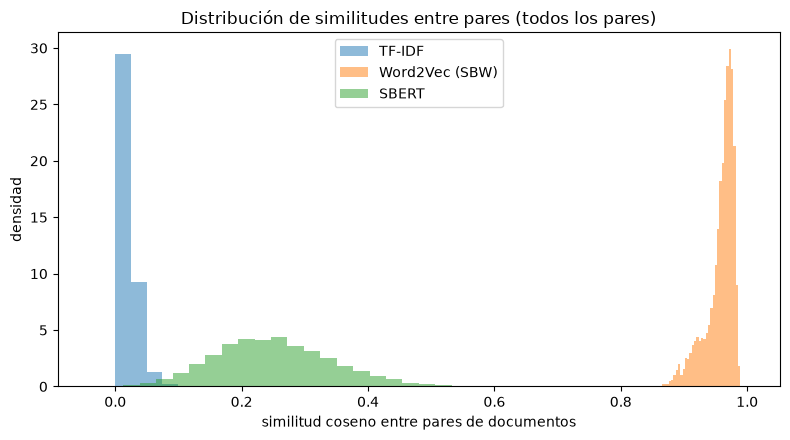

,media,desvio,min,max,rango
modelo,,,,,
TF-IDF,0.019,0.021,0.000,0.99,0.989
Word2Vec (SBW),0.958,0.023,0.854,1.00,0.146
SBERT,0.252,0.094,-0.039,1.00,1.039


In [27]:
def sims_pares(X):
    S = cosine_similarity(X)
    iu = np.triu_indices(X.shape[0], k=1)   # pares i<j, sin la diagonal
    return S[iu]

resumen = []
plt.figure(figsize=(8, 4.5))
for nombre, (X, _) in espacios.items():
    v = sims_pares(X)
    resumen.append({
        "modelo": nombre,
        "media":  v.mean(),
        "desvio": v.std(),
        "min":    v.min(),
        "max":    v.max(),
        "rango":  v.max() - v.min(),
    })
    plt.hist(v, bins=40, alpha=0.5, density=True, label=nombre)

plt.xlabel("similitud coseno entre pares de documentos")
plt.ylabel("densidad")
plt.title("Distribución de similitudes entre pares (todos los pares)")
plt.legend()
plt.tight_layout()
plt.show()

pd.DataFrame(resumen).set_index("modelo").round(3)

**Lectura de la distribución (resultados de esta corrida):**

| modelo | media | desvío | rango |
| --- | --- | --- | --- |
| TF-IDF | 0.019 | 0.021 | 0.989 |
| Word2Vec (SBW) | 0.958 | 0.023 | 0.146 |
| SBERT | 0.252 | 0.094 | 1.039 |

- **TF-IDF (media ≈ 0.02):** por dispersión, dos documentos cualesquiera son casi ortogonales. Discrimina por ausencia de solapamiento, pero eso mismo lo vuelve inútil cuando la consulta no usa las palabras exactas del documento (ver q11).
- **Word2Vec SBW (media ≈ 0.96, desvío ≈ 0.02):** **todo se parece a todo.** Promediar 300 dimensiones sobre textos largos colapsa los vectores hacia una dirección común; el ranking opera sobre diferencias de centésimas y es frágil. Es el caso de libro que la consigna advierte: aunque devuelva un orden, casi no separa.
- **SBERT (media ≈ 0.25, desvío ≈ 0.09):** media moderada y **el mayor desvío** de los tres → es el que más margen tiene para distinguir un par relevante de uno irrelevante. Coincide con que sea el mejor en los rankings de D.1.

### D.3 — Proyección 2D por género

Proyectamos los 120 documentos a 2D y los coloreamos por **género**, una etiqueta que ningún modelo vio durante el entrenamiento/ajuste. Como todo el corpus es "Realista", usamos como color el **primer género secundario** de cada libro (Novela, Relato, Drama, …), agrupando los menos frecuentes en "Otros".

Usamos **PCA** (informando la varianza explicada por las 2 componentes) para los tres espacios, y agregamos un **t-SNE** del espacio SBERT. Las dos lecturas tienen advertencias distintas, comentadas abajo.

In [28]:
# Etiqueta de género principal (el primer género que no sea "Realista")
def genero_principal(g):
    try:
        lst = ast.literal_eval(g) if isinstance(g, str) and g.strip().startswith("[") else str(g).split()
    except (ValueError, SyntaxError):
        lst = str(g).split()
    lst = [x for x in lst if x.lower() != "realista"]
    return lst[0] if lst else "Realista"

generos_doc = df_sbert["generos"].apply(genero_principal).to_numpy()

# Agrupar los géneros poco frecuentes para que la leyenda sea legible
top_generos = {g for g, _ in Counter(generos_doc).most_common(6)}
generos_plot = np.array([g if g in top_generos else "Otros" for g in generos_doc])

clases = sorted(set(generos_plot))
cmap = plt.get_cmap("tab10", len(clases))
color_de = {c: cmap(i) for i, c in enumerate(clases)}

print("Distribución de géneros usada para el color:")
print(pd.Series(generos_plot).value_counts())

Distribución de géneros usada para el color:
Novela       74
Drama        17
Relato       15
Otros        10
Histórico     3
Ensayo        1
Name: count, dtype: int64


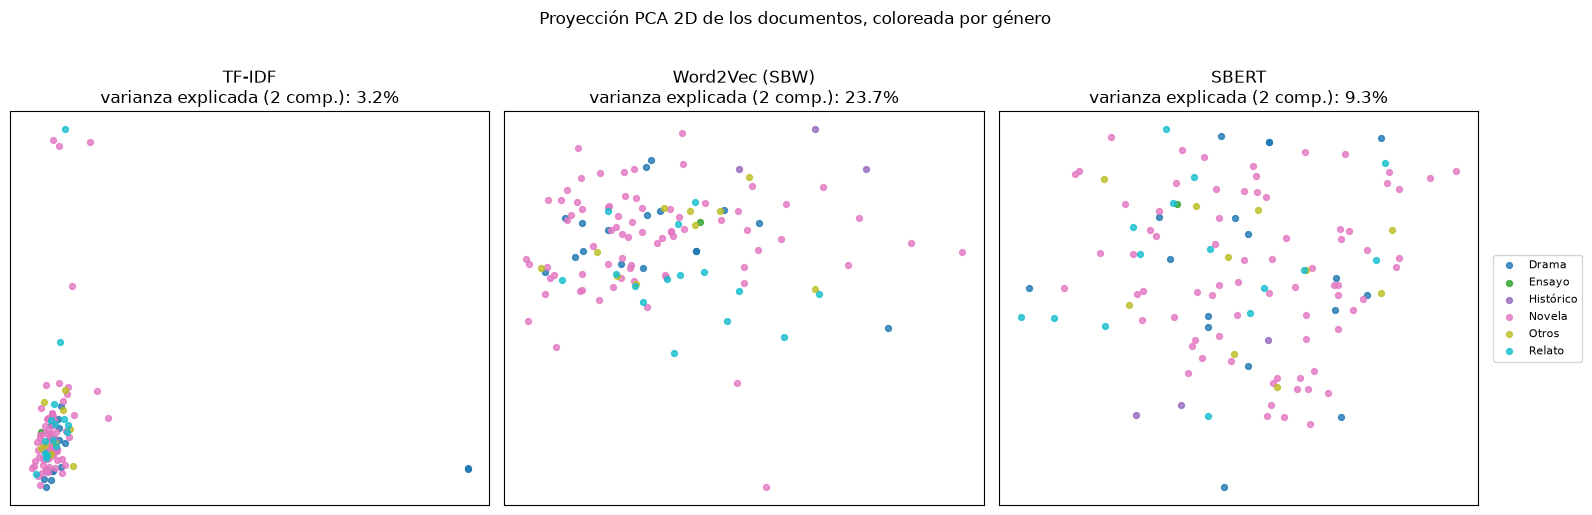

In [29]:
# --- PCA 2D de cada espacio, coloreado por género ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (nombre, (X, _)) in zip(axes, espacios.items()):
    pca = PCA(n_components=2, random_state=42)
    Z = pca.fit_transform(X)
    var = pca.explained_variance_ratio_[:2].sum() * 100
    for c in clases:
        m = generos_plot == c
        ax.scatter(Z[m, 0], Z[m, 1], s=18, alpha=0.8, color=color_de[c], label=c)
    ax.set_title(f"{nombre}\nvarianza explicada (2 comp.): {var:.1f}%")
    ax.set_xticks([]); ax.set_yticks([])

axes[-1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.suptitle("Proyección PCA 2D de los documentos, coloreada por género", y=1.02)
plt.tight_layout()
plt.show()

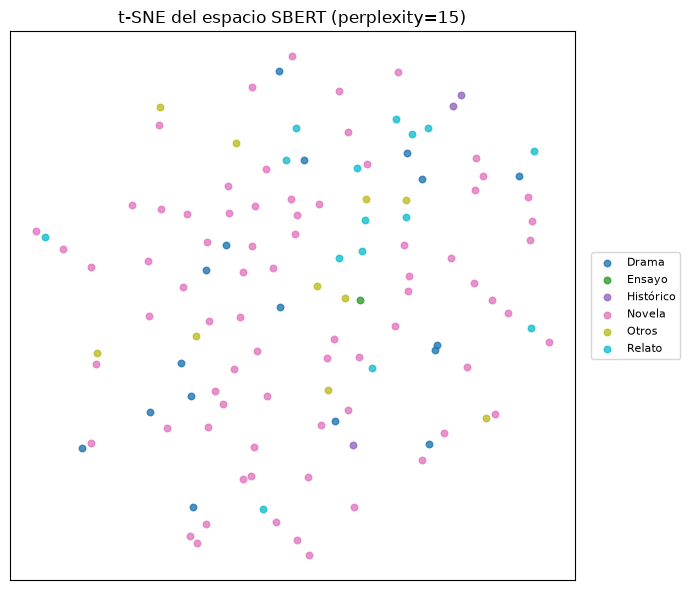

In [30]:
# --- t-SNE del espacio SBERT ---
perplexity = 15

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    init="pca",
    learning_rate="auto",
    random_state=42,
)
Zt = tsne.fit_transform(X_sbert)

plt.figure(figsize=(7, 6))
for c in clases:
    m = generos_plot == c
    plt.scatter(Zt[m, 0], Zt[m, 1], s=22, alpha=0.8, color=color_de[c], label=c)
plt.title(f"t-SNE del espacio SBERT (perplexity={perplexity})")
plt.xticks([]); plt.yticks([])
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

## Parte 5 — Evaluación de los modelos: precision@k

Un buscador que "devuelve resultados plausibles" no alcanza: `argsort` ordena ruido con la misma prolijidad con que ordena señal. Para medir de verdad usamos el conjunto de evaluación propio (`queries.json`, 13 consultas con sus relevantes juzgados a mano) y calculamos **precision@k**:

Comparamos cuatro recuperadores:

- **TF-IDF** — línea de base léxica (la del TP1).
- **Word2Vec (SBW)** y **SBERT** — los dos espacios de embeddings.
- **Azar (piso)** — ranking aleatorio, promediado sobre muchas permutaciones. Es la línea de base obligatoria: si el azar ya da alto porque un tema cubre media colección, superarlo apenas no es mérito.

> Requiere haber corrido antes la celda **D.0** (define `espacios`, `QUERIES`, `gold_ids`, `doc_ids`).

In [31]:
# --- Parte 5: precision@k por modelo, con piso al azar ---
K_LIST = [3, 5, 10]
N_RAND = 2000                      # permutaciones para estimar el piso
rng = np.random.default_rng(42)

def ranking_idx(texto, X, qfn):
    sims = cosine_similarity(qfn(texto), X)[0]
    return np.argsort(sims)[::-1]

def precision_at_k(ranked_idx, gold, k):
    topk = ranked_idx[:k]
    return sum(1 for i in topk if doc_ids[i] in gold) / k

modelos = list(espacios.keys()) + ["Azar (piso)"]
acc = {(m, k): [] for m in modelos for k in K_LIST}   # P@k por consulta
detalle = []                                          # tabla por consulta (P@5)

for qid, c in QUERIES.items():
    gold = gold_ids(qid)
    texto = c["texto"]
    fila = {"consulta": qid, "R": len(gold), "sin_solape": c["sin_solapamiento_lexico"]}

    # modelos reales
    for nombre, (X, qfn) in espacios.items():
        ridx = ranking_idx(texto, X, qfn)
        for k in K_LIST:
            p = precision_at_k(ridx, gold, k)
            acc[(nombre, k)].append(p)
            if k == 5:
                fila[nombre] = round(p, 2)

    # piso: promedio de N_RAND rankings aleatorios (≈ R/N, independiente de k)
    for k in K_LIST:
        base = np.arange(len(doc_ids))
        ps = []
        for _ in range(N_RAND):
            perm = base.copy()
            rng.shuffle(perm)
            ps.append(precision_at_k(perm, gold, k))
        acc[("Azar (piso)", k)].append(np.mean(ps))
        if k == 5:
            fila["Azar (piso)"] = round(np.mean(ps), 2)

    detalle.append(fila)

# Resumen: precision@k promedio sobre las 13 consultas
resumen = pd.DataFrame(
    {f"P@{k}": [np.mean(acc[(m, k)]) for m in modelos] for k in K_LIST},
    index=modelos,
).round(3)

print("precision@k promedio sobre", len(QUERIES), "consultas:")
resumen

precision@k promedio sobre 13 consultas:


,P@3,P@5,P@10
TF-IDF,0.282,0.200,0.169
Word2Vec (SBW),0.231,0.231,0.146
SBERT,0.487,0.477,0.331
Azar (piso),0.045,0.046,0.045


In [32]:
# Detalle por consulta (P@5): permite ver dónde gana o empata cada modelo
df_detalle = pd.DataFrame(detalle).set_index("consulta")
# orden de columnas legible
cols = ["R", "sin_solape", "TF-IDF", "Word2Vec (SBW)", "SBERT", "Azar (piso)"]
df_detalle = df_detalle[cols]
df_detalle

,R,sin_solape,TF-IDF,Word2Vec (SBW),SBERT,Azar (piso)
consulta,,,,,,
q01,7,False,0.0,0.0,0.4,0.06
q02,4,False,0.2,0.2,0.6,0.03
q03,8,False,0.0,0.4,0.4,0.07
q04,7,False,0.0,0.8,0.8,0.06
q05,5,False,0.2,0.2,0.6,0.04
q06,4,False,0.4,0.2,0.4,0.03
q07,6,False,0.0,0.2,0.6,0.05
q08,7,False,0.4,0.2,1.0,0.06
q09,2,False,0.4,0.0,0.2,0.02


**Lectura de los resultados (esta corrida):**

| recuperador | P@3 | P@5 | P@10 |
| --- | --- | --- | --- |
| TF-IDF | 0.282 | 0.200 | 0.169 |
| Word2Vec (SBW) | 0.231 | 0.231 | 0.146 |
| **SBERT** | **0.487** | **0.477** | **0.331** |
| Azar (piso) | 0.045 | 0.046 | 0.045 |

- **Todos superan el piso, pero no por igual.** El azar ronda **0.045** (coherente con la prevalencia media: ~5–6 relevantes sobre 120). SBERT (P@5 = **0.477**) le saca **~10×**; TF-IDF (0.200) y SBW (0.231) apenas **~4–5×**. Sin esta línea de base, un 0.20 podría parecer "bien"; contra el piso se ve que TF-IDF recupera señal real pero modesta.
- **SBERT es el claro ganador** en los tres cortes de k. Es el único que "entiende" consultas sin coincidencia de palabras (p. ej. q08 P@5 = 1.0, q07 = 0.6, q01 = 0.4, donde TF-IDF saca 0.0).
- **Word2Vec (SBW) no despega de TF-IDF** pese a ser semántico. Es consistente con la Parte D.2: con todas las similitudes apiladas en ~0.96, el espacio casi no discrimina, así que el orden que produce es poco mejor que el léxico.
- **TF-IDF empata o gana en q06, q09 y q13** — y es un resultado esperable, no un error. El motivo es puramente léxico: en esas consultas los libros relevantes **repiten las palabras de la consulta** en la sinopsis. Verificado sobre el corpus:
  - q13 ("adolescencia y paso a la vida adulta"): los relevantes contienen *adolescencia, joven, adulta, vida* → TF-IDF P@5 = 0.6 (gana).
  - q06 ("corrupción del poder político"): contienen *poder, corrupción, político, gobierno, Estado* → TF-IDF P@5 = 0.4 (empata con SBERT).
  - q09 ("emigrar… empezar de nuevo lejos de casa"): "Me llevaré el fuego" trae *país, nuevo, exilio* → TF-IDF P@5 = 0.4 (gana).
  Cuando consulta y documento comparten el vocabulario, TF-IDF acierta **sin necesidad de capturar significado**: ahí la ventaja semántica no se paga.
- **Consulta sin solapamiento léxico (q11, `sin_solape = True`):** TF-IDF da **P@5 = 0.0** por construcción (la consulta no comparte ninguna palabra con las dos sinopsis relevantes, que además son la misma novela en dos traducciones). SBW y SBERT recuperan 1 de 2 (**P@5 = 0.2**). Es el caso donde la diferencia entre representación léxica y semántica se vuelve visible.
- **Prevalencia (R) y techo de la métrica:** q09 y q11 tienen solo **R = 2 relevantes**, así que su P@5 no puede pasar de 0.4 aunque el modelo sea perfecto. Por eso P@k se lee junto con R, no en abstracto; el P@3 (más exigente en el tope del ranking) separa mejor a SBERT del resto.

**Conclusión:** sobre este corpus y estas consultas, el orden es **SBERT ≫ TF-IDF ≈ SBW ≫ azar**. La representación de oración (SBERT) es la única que generaliza más allá del vocabulario; TF-IDF sigue siendo competitivo justo cuando la consulta "habla el idioma" del documento, y el Word2Vec promediado no aporta sobre el léxico porque su espacio casi no discrimina.